In [72]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import openpyxl as pxl
import torch.nn.functional as F
import os
import re
import csv
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, r2_score


In [73]:
#General Parameters

alpha      = 0.5    # Bell curve coefficient
dropout    = 0.1   # Neuron deactivation (0 = off for small datasets)
epochs     = 800    # increased: force model had more to give
seed       = 42
patience   = 50    # increased: allow more time before early stop
batch_size = 32


In [74]:
#import Excel Data

notebook_dir = os.getcwd() #where is file located
file_path =os.path.join(notebook_dir,'Data','MLPartAB4.xlsx') #Read the file 

#read Excel with formulas using Openpyxl

wb = pxl.load_workbook(file_path) 
ws = wb.active 

headers = [ws.cell(1,col).value for col in range (1,ws.max_column+1)]

#Convert excel language to python

#extract names
letter_to_name = {}
for col in range(1,ws.max_column+1):
    letter = pxl.utils.get_column_letter(col)
    letter_to_name[letter] =headers[col-1]

def excel_to_python(formula, letter_to_name):
    result = formula
    result = result.lstrip('=')
    result = result.replace('$', '')
    result = re.sub(r'\bPI\(\)', 'np.pi', result)

    def replace_ref(match):
        letter = match.group(1)
        if letter in letter_to_name:
            name = letter_to_name[letter]
            return f"df['{name}']"
        return match.group(0)

    result = re.sub(r'\b([A-Z]{1,3})(\d+)\b', replace_ref, result)
    #extract the formulas
    excel_to_np = {
        'SIN'   : 'np.sin',
        'COS'   : 'np.cos',
        'TAN'   : 'np.tan',
        'ATAN'  : 'np.arctan',
        'ATAN2' : 'np.arctan2',
        'ASIN'  : 'np.arcsin',
        'ACOS'  : 'np.arccos',
        'SQRT'  : 'np.sqrt',
        'ABS'   : 'np.abs',
        'EXP'   : 'np.exp',
        'LOG'   : 'np.log',
        'LOG10' : 'np.log10',
        'POWER' : 'np.power',
        'MOD'   : 'np.mod',
        'FLOOR' : 'np.floor',
        'CEIL'  : 'np.ceil',
        'ROUND' : 'np.round',
        'MAX'   : 'np.maximum',
        'MIN'   : 'np.minimum',
        'SUM'   : 'np.sum',
    }

    for excel_fn, np_fn in excel_to_np.items():
        result = re.sub(rf'\b{excel_fn}\b', np_fn, result)

    result = result.replace('^', '**')
    result = result.lstrip('=')

    return result

#create a formula list

formula_list = {}
for col in range(1,ws.max_column+1):
    cell =ws.cell(2,col)
    value = cell.value
    name = headers[col-1]
    if isinstance(value,str) and value.startswith('='):
        formula_list[name]=excel_to_python(value,letter_to_name)

raw_cols = [h for h in headers if h not in formula_list]
# Formula columns to use as OUTPUT targets — read real Excel values, don't recompute
target_formulas = ['Torque', 'P_input']

formula_list_compute = {k: v for k, v in formula_list.items() if k not in target_formulas}
raw_cols = [h for h in headers if h not in formula_list_compute]

#find the values of the data provided in the excel and extract into a dataframe

def compute_features(df,formula_list):
    df = df.copy()
    remaining = dict(formula_list)
    max_passes = len(formula_list)+1
    passes =0 

    while remaining and passes < max_passes:
        passes +=1
        newly_computed=[]
        
        for col_name, expr in remaining.items():
            try:
                df[col_name]=eval(expr)
                newly_computed.append(col_name)
            except Exception:
                pass
        for col in newly_computed:
            del remaining[col]
        if not newly_computed:
            print(f"\n Warning Error Newly Computed")
            break
    return df

#Cleaning of the dataset to optain a final dataset for the training of the model 
wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active 
data    = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]
df_raw  = pd.DataFrame(data, columns=headers)
df_computed = compute_features(df_raw[raw_cols], formula_list_compute)
df_training = df_computed.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True) #drops invalid data
print(f"df_training shape: {df_training.shape}")   # should be (100, 28)


df_training shape: (796, 19)


In [75]:
# Verify 
# ── 8. Verify against Excel ───────────────────────────────────
print(f"\n{'='*60}")
print(f"  Verify — Python vs Excel (row 1)")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Excel':>12} | {'Python':>12} | {'Match':>6}")
print(f"{'-'*60}")

match_count = 0
for col in formula_list.keys():
    if col in df_raw.columns and col in df_computed.columns:
        excel_val  = df_raw[col].iloc[0]
        python_val = df_computed[col].iloc[0]
        if excel_val is not None and not pd.isna(excel_val):
            match = abs(excel_val - python_val) < 1e-4
            if match:
                match_count += 1
            print(f"{col:>15} | {excel_val:>12.4f} | {python_val:>12.4f} | "
                  f"{'✓' if match else '✗':>6}")

print(f"\n  Matched : {match_count} / {len(formula_list)} columns")
print(f"{'='*60}")

# ── 9. Final dataset summary ──────────────────────────────────
print(f"\n{'='*60}")
print(f"  FINAL DATASET")
print(f"{'='*60}")
print(f"  Shape   : {df_computed.shape}")
print(f"  Columns : {df_computed.columns.tolist()}")
print(f"\n{'='*60}")
print(f"  STATISTICS")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
print(f"{'-'*60}")
for col in df_computed.columns:
    vals = df_computed[col].dropna()
    if vals.dtype in [float, int]:
        print(f"{col:>15} | {vals.min():>12.4f} | "
              f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
print(f"{'='*60}")


  Verify — Python vs Excel (row 1)
         Column |        Excel |       Python |  Match
------------------------------------------------------------
         Torque |       1.4166 |       1.4166 |      ✓
        P_input |       5.7668 |       5.7668 |      ✓

  Matched : 2 / 2 columns

  FINAL DATASET
  Shape   : (3000, 19)
  Columns : ['r (m)', 'e (m)', 'L (m)', 'Ac (m²)', 'Ar (m²)', 'RPM', 'QRR', 'Torque', 'P_input', 'width (m)', 'height (m)', 'pin_dia (m)', '|RT0|max', '|P1|max', '|B0|max', 'FOS', 'N_to', 'N_Bo', 'N_P1']

  STATISTICS
         Column |          Min |          Max |         Mean
------------------------------------------------------------
          r (m) |       0.0200 |       0.2000 |       0.1107
          e (m) |       0.0100 |       0.0500 |       0.0300
          L (m) |       0.0680 |       1.1936 |       0.4983
        Ac (m²) |       0.0001 |       0.0010 |       0.0005
        Ar (m²) |       0.0001 |       0.0010 |       0.0006
            RPM |      15.

In [76]:
# Print formulas 
print(f"  Formula — {len(formula_list)} columns")
for col_name, expr in formula_list.items():
    print(f"\n  Column  : {col_name}")
    print(f"  Python  : {expr}")


  Formula — 2 columns

  Column  : Torque
  Python  : np.abs(df['|RT0|max']*df['r (m)']*np.cos(RADIANS(152)))

  Column  : P_input
  Python  : df['Torque']*df['RPM']*2*np.pi/60


In [77]:
# ── Target column definitions ──────────────────────────────────────────────────
force_cols   = ['P_input','|RT0|max', '|P1|max', '|B0|max','Torque']
fatigue_cols = ['N_to', 'N_Bo', 'N_P1']   # already log10 from Excel

target_col = force_cols + fatigue_cols
n_force    = len(force_cols)    # 7
n_fatigue  = len(fatigue_cols)  # 3
n_output   = len(target_col)    # 10


constant_cols = {}

def is_constant(series, cv_threshold=0.01):
    std  = float(series.std())
    mean = float(series.mean())
    if pd.isna(std) or std == 0:        return True
    if mean == 0 or pd.isna(mean):      return std < 1e-10
    return (std / abs(mean)) < cv_threshold

for col in df_training.columns:
    if col is None or col in target_col:
        continue
    series = df_training[col].dropna()
    if len(series) == 0:
        continue
    if is_constant(series):
        constant_cols[col] = float(series.iloc[0])


C  = df_training[list(constant_cols.keys())].copy()
Yf = df_training[force_cols].copy()
Ya = df_training[fatigue_cols].copy()   # already log10 from Excel
Y  = df_training[target_col].copy()
X  = df_training.drop(columns=target_col, errors='ignore').copy()
X  = X[[col for col in X.columns if col is not None]]

feature_cols = list(X.columns)


assert np.isfinite(Ya.values).all(), \
    f"Non-finite values in Ya — check log10 columns in Excel. " \
    f"Inf count: {np.isinf(Ya.values).sum()}"


x  = torch.tensor(X.values,  dtype=torch.float32)
yf = torch.tensor(Yf.values, dtype=torch.float32)
ya = torch.tensor(Ya.values, dtype=torch.float32)
y  = torch.tensor(Y.values,  dtype=torch.float32)
c  = torch.tensor(C.values,  dtype=torch.float32)

print(f"  Dataframe ")
print(f"\n  C  — Constants (also in X)     : {C.shape}")
print(f"       {C.columns.tolist()}")
print(f"\n  Yf — Force targets  (stage 1)  : {Yf.shape}")
print(f"       {Yf.columns.tolist()}")
print(f"\n  Ya — Fatigue targets (stage 2) : {Ya.shape}")
print(f"       {Ya.columns.tolist()}")
print(f"\n  X  — Features (incl. constants): {X.shape}")
print(f"       {X.columns.tolist()}")
print()
print(f"  x  tensor : {x.shape}   NaN: {torch.isnan(x).sum().item()}")
print(f"  yf tensor : {yf.shape}  NaN: {torch.isnan(yf).sum().item()}")
print(f"  ya tensor : {ya.shape}  NaN: {torch.isnan(ya).sum().item()}")
print(f"  c  tensor : {c.shape}   NaN: {torch.isnan(c).sum().item()}")
print(f"\n  ya range  : min={ya.min().item():.3f}  max={ya.max().item():.3f}")

  Dataframe 

  C  — Constants (also in X)     : (796, 0)
       []

  Yf — Force targets  (stage 1)  : (796, 5)
       ['P_input', '|RT0|max', '|P1|max', '|B0|max', 'Torque']

  Ya — Fatigue targets (stage 2) : (796, 3)
       ['N_to', 'N_Bo', 'N_P1']

  X  — Features (incl. constants): (796, 11)
       ['r (m)', 'e (m)', 'L (m)', 'Ac (m²)', 'Ar (m²)', 'RPM', 'QRR', 'width (m)', 'height (m)', 'pin_dia (m)', 'FOS']

  x  tensor : torch.Size([796, 11])   NaN: 0
  yf tensor : torch.Size([796, 5])  NaN: 0
  ya tensor : torch.Size([796, 3])  NaN: 0
  c  tensor : torch.Size([796, 0])   NaN: 0

  ya range  : min=6.886  max=49.405


In [78]:
#Parameters

num_workers=0   # cpu (AI Recommended)

class Training(Dataset):

    def __init__(self, x_mix, yf_mix,ya_mix):
        assert x_mix.shape[0] == yf_mix.shape[0]==ya_mix.shape[0]
        self.x_mix  = x_mix
        self.yf_mix  = yf_mix
        self.ya_mix=ya_mix

    def __len__(self):return self.x_mix.shape[0]
    def __getitem__(self, idx):
        return (self.x_mix[idx],self.yf_mix[idx],self.ya_mix[idx])

class Validation(Dataset):
    def __init__(self,x,yf,ya,c):
        assert x.shape[0] == yf.shape[0] ==ya.shape[0]== c.shape[0]
        self.x = x
        self.yf=yf
        self.ya=ya
        self.c = c

    def __len__(self):return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.yf[idx],self.ya[idx], self.c[idx]

def get_dataloaders(train_ds,val_ds,batch_size,num_workers,seed) -> tuple[DataLoader, DataLoader]:
    g = torch.Generator().manual_seed(seed) #shuffle generator

    train_loader = DataLoader(
        train_ds,
        batch_size  = batch_size,
        shuffle     = True,
        drop_last   = True,
        num_workers = num_workers,
        generator   = g, #shuffle
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = batch_size,
        shuffle     = False,
        drop_last   = False,
        num_workers = num_workers,
    )
    return train_loader, val_loader


class FatigueLoss(nn.Module):
    def __init__(self, delta=0.5, overpredict_weight=1.5):
        super().__init__()
        self.delta = delta
        self.w_over = overpredict_weight

    def forward(self, pred, target):
        error = pred - target
        abs_error = error.abs()

        # Huber: quadratic below delta, linear above
        quadratic = 0.5 * error ** 2
        linear    = self.delta * (abs_error - 0.5 * self.delta)
        huber     = torch.where(abs_error <= self.delta, quadratic, linear)

        # Asymmetric weight: pred > target = overprediction = dangerous
        weight = torch.where(error > 0,
                             self.w_over,
                             1.0)

        return (weight * huber).mean()


In [79]:
from sklearn.model_selection import train_test_split

def split_data(x, yf, ya, c, seed, train_frac=0.70, val_frac=0.15):
    n = len(x)
    test_frac = 1.0 - train_frac - val_frac

    # Stratify on FOS if available, otherwise bin primary force output
    fos_col_idx = None
    if 'FOS' in feature_cols:
        fos_col_idx = feature_cols.index('FOS')

    if fos_col_idx is not None:
        strata = x[:, fos_col_idx].numpy()
    else:
        # Bin the first force target into quantiles
        vals = yf[:, 0].numpy()
        strata = np.digitize(vals, np.percentile(vals, np.linspace(0, 100, 6)[1:-1]))

    indices = np.arange(n)

    # Split 1: train vs (val+test)
    train_idx, valtest_idx = train_test_split(
        indices, test_size=val_frac + test_frac,
        stratify=strata, random_state=seed)

    # Split 2: val vs test
    relative_test = test_frac / (val_frac + test_frac)
    valtest_strata = strata[valtest_idx]
    val_idx, test_idx = train_test_split(
        valtest_idx, test_size=relative_test,
        stratify=valtest_strata, random_state=seed)

    return (torch.tensor(train_idx), torch.tensor(val_idx),
            torch.tensor(test_idx))

def mixup(x, yf,ya, alpha=alpha, seed=seed):
    np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32).unsqueeze(1)
    idx_p = torch.randperm(N)

    x_mix = lam_t*x+(1-lam_t)*x[idx_p]
    yf_mix = lam_t*yf+(1-lam_t)*yf[idx_p]
    ya_mix = lam_t*ya+(1-lam_t)*ya[idx_p]

    return x_mix, yf_mix, ya_mix

train_idx, val_idx, test_idx = split_data(x, yf, ya, c, seed)

In [80]:
class Sohoite_Force(nn.Module):
    def __init__(self, input_dim, n_force=n_force, dropout=dropout):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(n_force)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h1 = self.hidden1(x)
        h2 = self.hidden2(h1)
        return torch.cat([head(h2) for head in self.heads], dim=1)
    
""""
Notes from PyTorch Documentation and Class 
- Linear is the based feature of any code 
- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm 
- Relu: This is the activation function recommended by Dr. Ince
- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero

Before starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid
""" 

'"\nNotes from PyTorch Documentation and Class \n- Linear is the based feature of any code \n- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm \n- Relu: This is the activation function recommended by Dr. Ince\n- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero\n\nBefore starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid\n'

In [81]:
class Sohoite_Fatigue(nn.Module):
    def __init__(self, input_dim, n_force=n_force, n_fatigue=n_fatigue, dropout=dropout):
        super().__init__()
        combined_dim = input_dim + n_force

        self.hidden1 = nn.Sequential(
            nn.Linear(combined_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.skip = nn.Linear(combined_dim, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_fatigue)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, Force_P):
        combined = torch.cat([x, Force_P], dim=1)
        h1 = self.hidden1(combined)
        h2 = self.hidden2(h1)
        h2 = h2 + self.skip(combined)
        return torch.cat([head(h2) for head in self.heads], dim=1)









In [82]:
# Functions

def train_force_epoch(force_model, loader, optimizer, device,
                      x_mean, x_std, yf_mean, yf_std):
    force_model.train()
    criterion  = nn.MSELoss()
    total_loss = 0.0

    for x_mix, yf_mix, _ in loader:
        x_mix  = x_mix.to(device)
        yf_mix = yf_mix.to(device)

        optimizer.zero_grad()
        pred_forces = force_model(x_mix)
        loss = criterion(pred_forces, yf_mix)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(force_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)


def train_fatigue_epoch(force_model, fatigue_model, loader, optimizer, device,
                        x_mean, x_std, yf_mean, yf_std, ya_mean, ya_std):
    force_model.eval()
    fatigue_model.train()
    criterion  = FatigueLoss(delta=0.5, overpredict_weight=1.5)  # ← here
    total_loss = 0.0

    for x_mix, _, ya_mix in loader:
        x_mix  = x_mix.to(device)
        ya_mix = ya_mix.to(device)

        optimizer.zero_grad()
        with torch.no_grad():
            pred_forces = force_model(x_mix)

        pred_fatigue = fatigue_model(x_mix, pred_forces)
        loss = criterion(pred_fatigue, ya_mix)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fatigue_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_force(force_model, loader, device):
    force_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pf, all_tf = [], []

    for x_batch, yf_batch, ya_batch, _ in loader:   # Validation yields 4 items
        x_batch  = x_batch.to(device)
        yf_batch = yf_batch.to(device)

        pred_f = force_model(x_batch)
        total_loss += criterion(pred_f, yf_batch).item() * len(x_batch)
        all_pf.append(pred_f.cpu())
        all_tf.append(yf_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pf), torch.cat(all_tf),
    )


@torch.no_grad()
def evaluate_fatigue(force_model, fatigue_model, loader, device):
    force_model.eval()
    fatigue_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pa, all_ta = [], []

    for x_batch, yf_batch, ya_batch, _ in loader:   # Validation yields 4 items
        x_batch  = x_batch.to(device)
        ya_batch = ya_batch.to(device)

        pred_f  = force_model(x_batch)               # cascade
        pred_fa = fatigue_model(x_batch, pred_f)
        total_loss += criterion(pred_fa, ya_batch).item() * len(x_batch)
        all_pa.append(pred_fa.cpu())
        all_ta.append(ya_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pa), torch.cat(all_ta),
    )


def tester(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae


In [83]:


device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
) # AI recommended 




In [84]:
# Set Up
x_tr  = x[train_idx];  yf_tr  = yf[train_idx];   ya_tr = ya[train_idx]
x_val = x[val_idx];    yf_val = yf[val_idx];      ya_val = ya[val_idx]
x_te  = x[test_idx];   yf_te  = yf[test_idx];      ya_te = ya[test_idx]
c_val = c[val_idx];    c_te  = c[test_idx]

x_mean = x_tr.mean(dim=0)
x_std  = x_tr.std(dim=0).clamp(min=1e-8)
yf_mean = yf_tr.mean(dim=0)                  
yf_std  = yf_tr.std(dim=0).clamp(min=1e-8)
ya_mean = ya_tr.mean(dim=0)                  
ya_std  = ya_tr.std(dim=0).clamp(min=1e-8)  

x_tr_norm  = (x_tr  - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_te_norm  = (x_te  - x_mean) / x_std
yf_tr_norm  = (yf_tr  - yf_mean) / yf_std
yf_val_norm = (yf_val - yf_mean) / yf_std
yf_te_norm  = (yf_te  - yf_mean) / yf_std
ya_tr_norm  = (ya_tr  - ya_mean) / ya_std
ya_val_norm = (ya_val - ya_mean) / ya_std
ya_te_norm  = (ya_te  - ya_mean) / ya_std


# Define static datasets (val and test never change)
val_ds  = Validation(x_val_norm, yf_val_norm,ya_val_norm, c_val)
test_ds = Validation(x_te_norm,  yf_te_norm, ya_te_norm,  c_te)

val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

#Two Stage Models
force_model = Sohoite_Force(input_dim=x.shape[1]).to(device)
fatigue_model =Sohoite_Fatigue(input_dim=x.shape[1]).to(device)

# ── Stronger weight decay ────────────────────────────────────
optimizer_force = optim.AdamW(force_model.parameters(),
                              lr=1e-4, weight_decay=5e-3)   # was 1e-3


best_force_val    = float('inf')
best_force_state  = None
epochs_no_improve = 0
stopped_force     = epochs
force_train_hist  = []
force_val_hist    = []

print("  Stage 1 — Force")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,
                                      batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss          = train_force_epoch(force_model, train_loader, optimizer_force,
                                         device, x_mean, x_std, yf_mean, yf_std)
    val_loss, _, _   = evaluate_force(force_model, val_loader, device)


    force_train_hist.append(tr_loss)
    force_val_hist.append(val_loss)

    if val_loss < best_force_val:
        best_force_val   = val_loss
        best_force_state = {k: v.clone() for k, v in force_model.state_dict().items()}
        epochs_no_improve = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_force = epoch
        break

print(f'\n  Stopped : epoch {stopped_force}  |  Best val loss : {best_force_val:.6f}')
force_model.load_state_dict(best_force_state)

# Freeze ForceNet — no gradients will flow through it in Stage 2
for p in force_model.parameters():
    p.requires_grad = False

optimizer_fatigue = optim.AdamW(fatigue_model.parameters(),
                                lr=1e-4, weight_decay=5e-3)
best_fatigue_val    = float('inf')
best_fatigue_state  = None
epochs_no_improve   = 0
stopped_fatigue     = epochs
fatigue_train_hist  = []
fatigue_val_hist    = []

print("\n  Stage 2 — Fatigue (ForceNet frozen)")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    x_mix, yf_mix, ya_mix = mixup(x_tr_norm, yf_tr_norm, ya_tr_norm,
                                   alpha=alpha, seed=epoch)
    train_ds        = Training(x_mix, yf_mix, ya_mix)
    train_loader, _ = get_dataloaders(train_ds, val_ds,batch_size=batch_size, num_workers=0, seed=epoch)

    tr_loss        = train_fatigue_epoch(force_model, fatigue_model, train_loader,optimizer_fatigue, device,x_mean,x_std,yf_mean,yf_std,ya_mean,ya_std)
    val_loss, _, _ = evaluate_fatigue(force_model, fatigue_model, val_loader, device)

    fatigue_train_hist.append(tr_loss)
    fatigue_val_hist.append(val_loss)

    if val_loss < best_fatigue_val:
        best_fatigue_val   = val_loss
        best_fatigue_state = {k: v.clone() for k, v in fatigue_model.state_dict().items()}
        epochs_no_improve  = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_fatigue = epoch
        break

print(f'\n  Stopped : epoch {stopped_fatigue}  |  Best val loss : {best_fatigue_val:.6f}')
fatigue_model.load_state_dict(best_fatigue_state)

# Evaluate
val_floss,  pf_val, tf_val = evaluate_force(force_model,   val_loader,  device)
test_floss, pf_te,  tf_te  = evaluate_force(force_model,   test_loader, device)
val_aloss,  pa_val, ta_val = evaluate_fatigue(force_model, fatigue_model, val_loader,  device)
test_aloss, pa_te,  ta_te  = evaluate_fatigue(force_model, fatigue_model, test_loader, device)

val_force_res,  val_force_mae  = tester(pf_val, tf_val, yf_mean, yf_std, force_cols)
test_force_res, test_force_mae = tester(pf_te,  tf_te,  yf_mean, yf_std, force_cols)
val_fat_res,    val_fat_mae    = tester(pa_val, ta_val, ya_mean, ya_std, fatigue_cols)
test_fat_res,   test_fat_mae   = tester(pa_te,  ta_te,  ya_mean, ya_std, fatigue_cols)

pf_val_w = (pf_val * yf_std + yf_mean).numpy(); tf_val_w = (tf_val * yf_std + yf_mean).numpy()
pf_te_w  = (pf_te  * yf_std + yf_mean).numpy(); tf_te_w  = (tf_te  * yf_std + yf_mean).numpy()
pa_val_w = (pa_val * ya_std + ya_mean).numpy(); ta_val_w = (ta_val * ya_std + ya_mean).numpy()
pa_te_w  = (pa_te  * ya_std + ya_mean).numpy(); ta_te_w  = (ta_te  * ya_std + ya_mean).numpy()

print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>10} | {val_fat_res[col]["mae"]:>9.4f} | '
          f'{val_fat_res[col]["r2"]:>8.4f} | '
          f'{test_fat_res[col]["mae"]:>9.4f} | '
          f'{test_fat_res[col]["r2"]:>8.4f}')


  Stage 1 — Force
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     1.281387 |   0.709090 | *
      50 |     0.903443 |   0.108468 |  
     100 |     0.740087 |   0.084830 | *
     150 |     0.334303 |   0.077248 | *
     200 |     0.825402 |   0.074136 |  
     250 |     0.532658 |   0.071418 |  
     300 |     0.563048 |   0.071094 |  

  Stopped : epoch 324  |  Best val loss : 0.067139

  Stage 2 — Fatigue (ForceNet frozen)
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     0.740417 |   3.876114 | *
      50 |     0.160409 |   0.328307 | *
     100 |     0.122187 |   0.242335 | *
     150 |     0.104900 |   0.227518 |  
     200 |     0.091502 |   0.223818 |  
     250 |     0.084409 |   0.217306 |  
     300 |     0.083735 |   0.210178 |  
     350 |     0.081431 |   0.205243 |  
     400 |     0.071780 |   0.205081 |  

  Stopped : epoch 401  |  Best val loss : 0.202465

      Output |   V

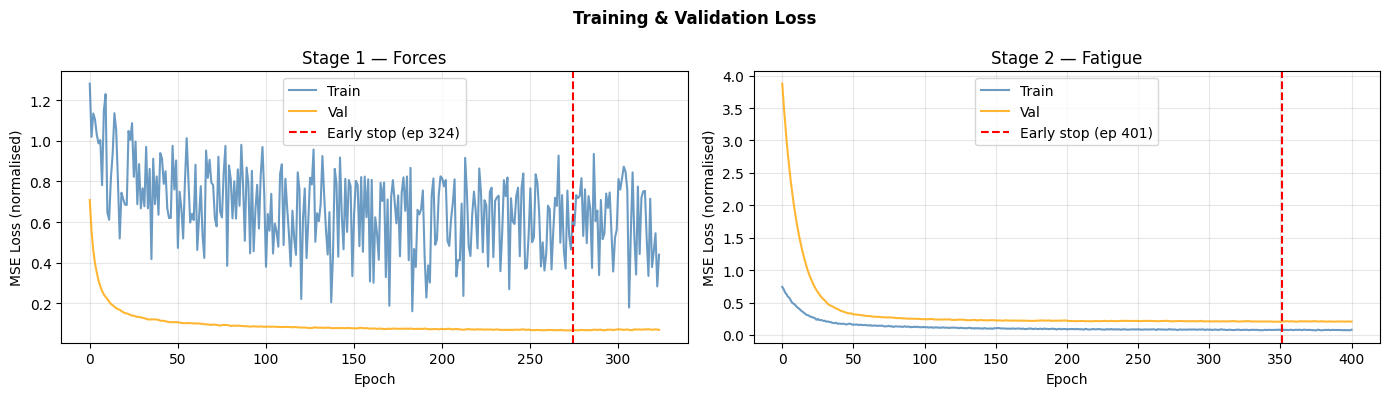

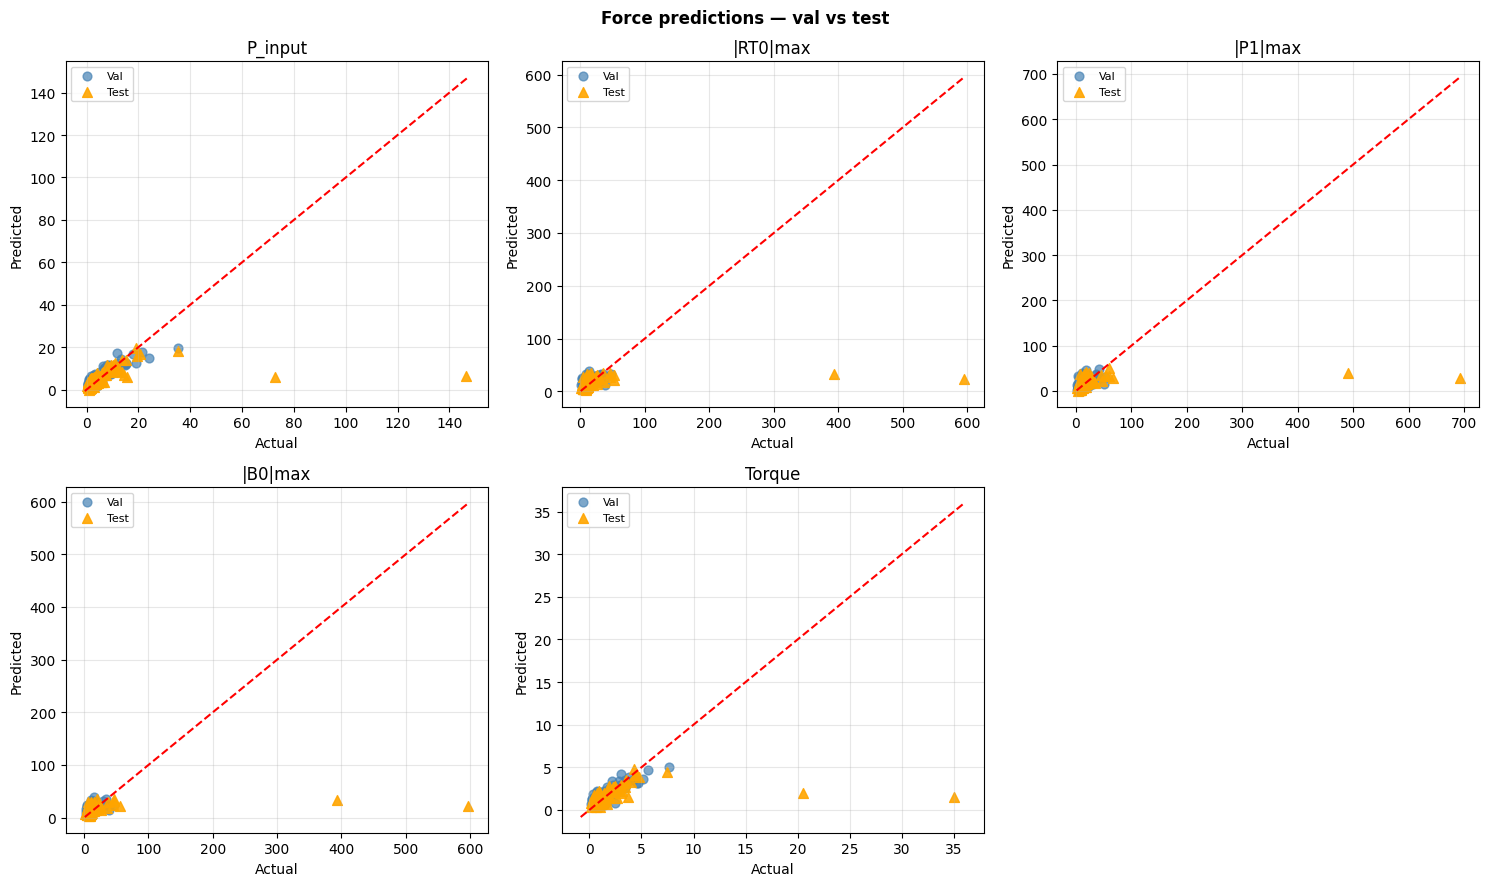

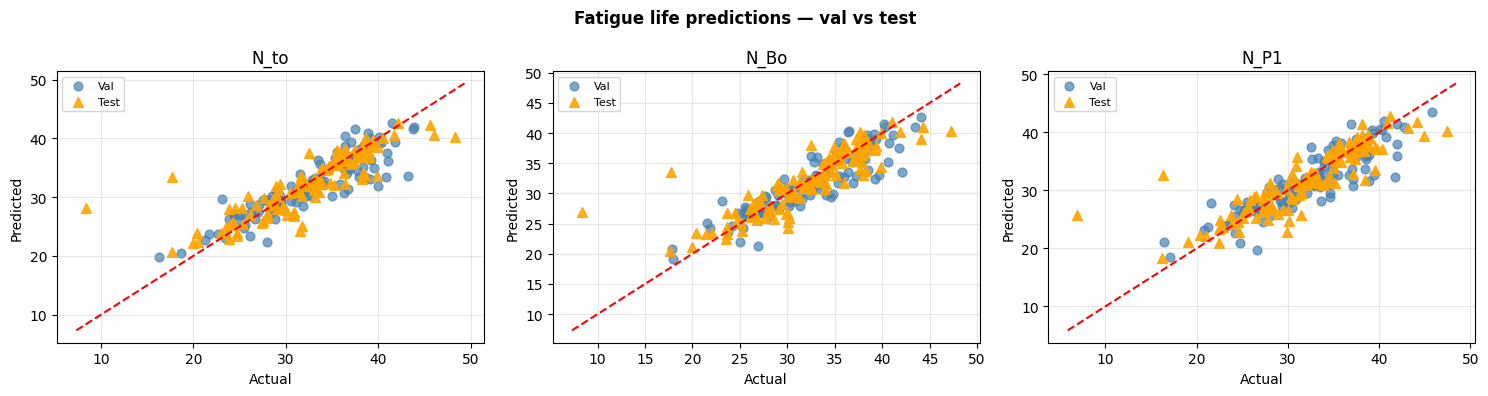

  Residuals
  -----------------------------------------------------------------
      Output |   Set |     Bias |      Std |  Max Err
  -----------------------------------------------------------------
  --- Forces ---
     P_input |   Val |  +0.3688 |   2.5473 |  15.5885
     P_input |  Test |  -1.5553 |  14.2813 | 140.0349
    |RT0|max |   Val |  +2.9105 |   7.2516 |  26.9666
    |RT0|max |  Test |  -5.9906 |  61.8498 | 571.5594
     |P1|max |   Val |  +2.3637 |   8.7834 |  34.6204
     |P1|max |  Test |  -7.8737 |  73.3118 | 663.0214
     |B0|max |   Val |  +2.7545 |   7.3320 |  25.4542
     |B0|max |  Test |  -5.6686 |  62.0506 | 574.1104
      Torque |   Val |  +0.1262 |   0.6150 |   2.6187
      Torque |  Test |  -0.3622 |   3.5315 |  33.5289
  --- Fatigue ---
        N_to |   Val |  -0.5945 |   2.5591 |   9.6799
        N_to |  Test |  -0.1391 |   3.2986 |  19.8602
        N_Bo |   Val |  -0.6877 |   2.4200 |   8.6481
        N_Bo |  Test |  -0.0382 |   3.1001 |  18.6056
       

In [85]:
# ── Loss curve ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training & Validation Loss', fontweight='bold')
for ax, train_h, val_h, stopped, title in [
    (axes[0], force_train_hist,   force_val_hist,   stopped_force,   'Stage 1 — Forces'),
    (axes[1], fatigue_train_hist, fatigue_val_hist, stopped_fatigue, 'Stage 2 — Fatigue'),
]:
    ax.plot(train_h, label='Train', color='steelblue', alpha=0.8)
    ax.plot(val_h,   label='Val',   color='orange',    alpha=0.8)
    ax.axvline(stopped - patience, color='red', linestyle='--', label=f'Early stop (ep {stopped})')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (normalised)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Force predictions scatter ──────────────────────────────────────────────────
n_f = len(force_cols)
fig, axes = plt.subplots(2, (n_f + 1) // 2, figsize=(5 * ((n_f + 1) // 2), 9))
fig.suptitle('Force predictions — val vs test', fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(force_cols):
    ax = axes[i]
    ax.scatter(tf_val_w[:, i], pf_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(tf_te_w[:,  i], pf_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(tf_val_w[:, i].min(), tf_te_w[:, i].min()) - 1
    hi = max(tf_val_w[:, i].max(), tf_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for ax in axes[n_f:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('force_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fatigue predictions scatter ────────────────────────────────────────────────
n_a = len(fatigue_cols)
fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 4))
fig.suptitle('Fatigue life predictions — val vs test', fontweight='bold')
for i, col in enumerate(fatigue_cols):
    ax = axes[i]
    ax.scatter(ta_val_w[:, i], pa_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(ta_te_w[:,  i], pa_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(ta_val_w[:, i].min(), ta_te_w[:, i].min()) - 1
    hi = max(ta_val_w[:, i].max(), ta_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fatigue_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Residual table ─────────────────────────────────────────────────────────────
print('  Residuals')
print('  ' + '-'*65)
print(f'  {"Output":>10} | {"Set":>5} | {"Bias":>8} | {"Std":>8} | {"Max Err":>8}')
print('  ' + '-'*65)
for group_name, cols, pv, tv, pt, tt in [
    ('Forces',  force_cols,   pf_val_w, tf_val_w, pf_te_w, tf_te_w),
    ('Fatigue', fatigue_cols, pa_val_w, ta_val_w, pa_te_w, ta_te_w),
]:
    print(f'  --- {group_name} ---')
    for i, col in enumerate(cols):
        for label, yp, yt in [('Val', pv, tv), ('Test', pt, tt)]:
            err = yp[:, i] - yt[:, i]
            print(f'  {col:>10} | {label:>5} | {err.mean():>+8.4f} | '
                  f'{err.std():>8.4f} | {np.abs(err).max():>8.4f}')
print('  ' + '-'*65)


In [86]:
print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')


      Output |   Val MAE |   Val R2 |  Test MAE |  Test R2
  ----------------------------------------------------------
     P_input |    1.6694 |   0.7640 |    3.2150 |   0.0907
    |RT0|max |    5.4490 |   0.1144 |   12.8004 |   0.0469
     |P1|max |    6.1027 |   0.0484 |   15.3385 |   0.0568
     |B0|max |    5.6214 |  -0.1150 |   13.1119 |   0.0447
      Torque |    0.4580 |   0.7317 |    0.8514 |   0.0725


In [87]:
# ══════════════════════════════════════════════════════════════════
#  Experiment Logger — paste after both stages finish
# ══════════════════════════════════════════════════════════════════

# ── Auto-read run number ─────────────────────────────────────────
log_file   = 'experiment_log.csv'
run_number = 0
if os.path.isfile(log_file):
    df_log     = pd.read_csv(log_file)
    run_number = len(df_log)

# ── Auto-detect config from models ───────────────────────────────
dropout_val = 0.0
for module in force_model.modules():
    if isinstance(module, nn.Dropout):
        dropout_val = module.p; break

norm_type = 'None'
for module in force_model.modules():
    if isinstance(module, nn.LayerNorm):
        norm_type = 'LayerNorm'; break
    elif isinstance(module, nn.BatchNorm1d):
        norm_type = 'BatchNorm1d'; break

has_skip = hasattr(force_model, 'skip')

hidden1_layers = [type(m).__name__ for m in force_model.hidden1]
hidden2_layers = [type(m).__name__ for m in force_model.hidden2]
force_arch = ' → '.join(hidden1_layers) + '  |  ' + ' → '.join(hidden2_layers)

fat_h1 = [type(m).__name__ for m in fatigue_model.hidden1]
fat_h2 = [type(m).__name__ for m in fatigue_model.hidden2]
fatigue_arch = ' → '.join(fat_h1) + '  |  ' + ' → '.join(fat_h2)

n_params_force   = sum(p.numel() for p in force_model.parameters())
n_params_fatigue = sum(p.numel() for p in fatigue_model.parameters())

# ── Hidden layer widths ──────────────────────────────────────────
force_widths   = ''
fatigue_widths = ''
for m in force_model.hidden1:
    if isinstance(m, nn.Linear):
        w1 = m.out_features; break
for m in force_model.hidden2:
    if isinstance(m, nn.Linear):
        w2 = m.out_features; break
force_widths = f'{w1} → {w2}'

for m in fatigue_model.hidden1:
    if isinstance(m, nn.Linear):
        fw1 = m.out_features; break
for m in fatigue_model.hidden2:
    if isinstance(m, nn.Linear):
        fw2 = m.out_features; break
fatigue_widths = f'{fw1} → {fw2}'
if has_skip:
    force_widths   += ' + skip'
    fatigue_widths += ' + skip'

# ── Build config dict ────────────────────────────────────────────
run_config = {
    'run_number'       : run_number + 1,
    'timestamp'        : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'split_method'     : 'stratified',          # ← update when you change it
    'loss_force'       : type(nn.HuberLoss()).__name__,   # ← match your criterion
    'loss_fatigue'     : 'FatigueLoss',                   # ← match your criterion
    'hidden_force'     : force_widths,
    'hidden_fatigue'   : fatigue_widths,
    'force_arch'       : force_arch,
    'fatigue_arch'     : fatigue_arch,
    'norm_type'        : norm_type,
    'skip_connection'  : has_skip,
    'n_params_force'   : n_params_force,
    'n_params_fatigue' : n_params_fatigue,
    'optimizer'        : type(optimizer_force).__name__,
    'lr'               : optimizer_force.param_groups[0]['lr'],
    'weight_decay'     : optimizer_force.param_groups[0].get('weight_decay', 0),
    'dropout'          : dropout_val,
    'lambda_pinn'      : Lambda,
    'CHECK'            : str(CHECK),
    'epochs_max'       : epochs,
    'stopped_force'    : stopped_force,
    'stopped_fatigue'  : stopped_fatigue,
    'best_force_val'   : round(best_force_val, 6),
    'best_fatigue_val' : round(best_fatigue_val, 6),
    'patience'         : patience,
    'batch_size'       : batch_size,
    'alpha_mixup'      : alpha,
    'n_force_outputs'  : n_force,
    'n_fatigue_outputs': n_fatigue,
    'seed'             : seed,
    'n_total'          : len(x),
    'n_train'          : len(train_idx),
    'n_val'            : len(val_idx),
    'n_test'           : len(test_idx),
    'pct_train'        : round(len(train_idx)/len(x)*100, 1),
    'pct_val'          : round(len(val_idx)/len(x)*100,   1),
    'pct_test'         : round(len(test_idx)/len(x)*100,  1),
    'notes'            : '',                     # ← add notes per run
}

# ── Collect metrics ──────────────────────────────────────────────
run_metrics = {}
for col in force_cols:
    for split, res in [('val', val_force_res), ('test', test_force_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(res[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_mse']  = round(res[col]['rmse']**2, 4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)

for col in fatigue_cols:
    for split, res in [('val', val_fat_res), ('test', test_fat_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(res[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_mse']  = round(res[col]['rmse']**2, 4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)

# ── Mean summaries ───────────────────────────────────────────────
for split in ['val', 'test']:
    force_r2s  = [run_metrics[f'{c}_{split}_r2']  for c in force_cols]
    force_maes = [run_metrics[f'{c}_{split}_mae'] for c in force_cols]
    fat_r2s    = [run_metrics[f'{c}_{split}_r2']  for c in fatigue_cols]
    fat_maes   = [run_metrics[f'{c}_{split}_mae'] for c in fatigue_cols]

    run_metrics[f'force_mean_{split}_r2']   = round(np.mean(force_r2s),  4)
    run_metrics[f'force_mean_{split}_mae']  = round(np.mean(force_maes), 4)
    run_metrics[f'fatigue_mean_{split}_r2'] = round(np.mean(fat_r2s),    4)
    run_metrics[f'fatigue_mean_{split}_mae']= round(np.mean(fat_maes),   4)

# ── Write to CSV (handles new columns across runs) ───────────────
row = {**run_config, **run_metrics}

if os.path.isfile(log_file):
    existing = pd.read_csv(log_file)
    new_row  = pd.DataFrame([row])
    combined = pd.concat([existing, new_row], ignore_index=True)
else:
    combined = pd.DataFrame([row])

combined.to_csv(log_file, index=False)

# ── Summary print ────────────────────────────────────────────────
print('=' * 70)
print(f'  Run {run_config["run_number"]} logged → {log_file}')
print('=' * 70)
print(f'  Split         : {run_config["split_method"]}  '
      f'({run_config["pct_train"]}/{run_config["pct_val"]}/{run_config["pct_test"]}%)')
print(f'  Loss          : force={run_config["loss_force"]}  '
      f'fatigue={run_config["loss_fatigue"]}')
print(f'  Force arch    : {force_widths}  ({n_params_force:,} params)')
print(f'  Fatigue arch  : {fatigue_widths}  ({n_params_fatigue:,} params)')
print(f'  Norm          : {norm_type}   Skip: {has_skip}')
print(f'  Optimizer     : {run_config["optimizer"]}  lr={run_config["lr"]}  '
      f'wd={run_config["weight_decay"]}')
print(f'  Dropout       : {dropout_val}   Mixup α: {alpha}')
print(f'  Stopped       : force={stopped_force}  fatigue={stopped_fatigue}  / {epochs}')
print(f'  Best val loss : force={best_force_val:.6f}  '
      f'fatigue={best_fatigue_val:.6f}')
print('-' * 70)
print(f'  {"Output":>12} | {"Val MAE":>8} | {"Val RMSE":>9} | {"Val R²":>7} | '
      f'{"Test MAE":>9} | {"Test RMSE":>10} | {"Test R²":>8}')
print(f'  {"-"*68}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>12} | '
          f'{run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_rmse"]:>9.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_rmse"]:>10.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f}')
print(f'  {"MEAN":>12} | '
      f'{run_metrics["force_mean_val_mae"]:>8.4f} | {"":>9} | '
      f'{run_metrics["force_mean_val_r2"]:>7.4f} | '
      f'{run_metrics["force_mean_test_mae"]:>9.4f} | {"":>10} | '
      f'{run_metrics["force_mean_test_r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>12} | '
          f'{run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_rmse"]:>9.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_rmse"]:>10.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f}')
print(f'  {"MEAN":>12} | '
      f'{run_metrics["fatigue_mean_val_mae"]:>8.4f} | {"":>9} | '
      f'{run_metrics["fatigue_mean_val_r2"]:>7.4f} | '
      f'{run_metrics["fatigue_mean_test_mae"]:>9.4f} | {"":>10} | '
      f'{run_metrics["fatigue_mean_test_r2"]:>8.4f}')
print('=' * 70)

NameError: name 'Lambda' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  SHAP Analysis — paste as a new cell after evaluation
# ══════════════════════════════════════════════════════════════════

import shap

# ── Wrapper functions (SHAP needs numpy in → numpy out) ──────────

class ForceWrapper:
    """Wraps force_model for SHAP: numpy → numpy."""
    def __init__(self, model, device):
        self.model  = model
        self.device = device
        self.model.eval()

    def __call__(self, X):
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(self.device)
            return self.model(t).cpu().numpy()


class FatigueWrapper:
    """Wraps the full cascade (force → fatigue) for SHAP."""
    def __init__(self, force_model, fatigue_model, device):
        self.force_model   = force_model
        self.fatigue_model = fatigue_model
        self.device        = device
        self.force_model.eval()
        self.fatigue_model.eval()

    def __call__(self, X):
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(self.device)
            pred_f = self.force_model(t)
            pred_a = self.fatigue_model(t, pred_f)
            return pred_a.cpu().numpy()


# ── Background data (use training set, subsample for speed) ──────

n_background = min(200, len(x_tr_norm))
bg_idx       = np.random.choice(len(x_tr_norm), n_background, replace=False)
background   = x_tr_norm[bg_idx].numpy()


# ── Helper: normalise shap_values into (n_outputs, n_samples, n_features) ──

def normalise_shap(sv):
    """
    Accepts either:
      - list of arrays, each (n_samples, n_features)         → old SHAP
      - 3-D array (n_samples, n_features, n_outputs)         → new SHAP
      - 2-D array (n_samples, n_features)  [single output]
    Returns: list of 2-D arrays, one per output.
    """
    if isinstance(sv, list):
        return sv
    if sv.ndim == 3:
        # (n_samples, n_features, n_outputs) → list of (n_samples, n_features)
        return [sv[:, :, i] for i in range(sv.shape[2])]
    # single output
    return [sv]


# ── Feature names ────────────────────────────────────────────────

n_model_features = background.shape[1]
if len(feature_cols) == n_model_features:
    shap_feature_names = list(feature_cols)
else:
    print(f'  ⚠ feature_cols has {len(feature_cols)} entries but model '
          f'has {n_model_features} inputs — using generic names')
    shap_feature_names = [f'Feature {i}' for i in range(n_model_features)]


# ══════════════════════════════════════════════════════════════════
#  Stage 1: Force SHAP
# ══════════════════════════════════════════════════════════════════

print('  Computing SHAP for ForceNet...')

force_fn        = ForceWrapper(force_model, device)
force_explainer = shap.KernelExplainer(force_fn, background)

n_explain   = min(100, len(x_te_norm))
explain_idx = np.random.choice(len(x_te_norm), n_explain, replace=False)
X_explain   = x_te_norm[explain_idx].numpy()

force_shap_raw    = force_explainer.shap_values(X_explain)
force_shap_list   = normalise_shap(force_shap_raw)   # list of (n_samples, n_features)
n_force_outputs   = len(force_shap_list)

print(f'  X_explain.shape:  {X_explain.shape}')
print(f'  Force outputs:    {n_force_outputs}')
print(f'  Per-output shape: {force_shap_list[0].shape}')

# ── Summary bar plot: mean |SHAP| across all force outputs ──────

mean_abs_shap = np.mean(
    np.stack([np.mean(np.abs(sv), axis=0) for sv in force_shap_list], axis=0),
    axis=0,
)  # (n_features,)

top_k      = min(15, len(mean_abs_shap))
sorted_idx = np.argsort(mean_abs_shap)[::-1]
top_idx    = sorted_idx[:top_k]

fig, ax = plt.subplots(figsize=(8, 6))
vals = mean_abs_shap[top_idx][::-1]
ax.barh(range(len(vals)), vals, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels([shap_feature_names[i] for i in top_idx][::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Stage 1 — ForceNet: Feature Importance (all outputs)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('shap_force_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Detailed beeswarm per force output ───────────────────────────

for i, col in enumerate(force_cols):
    if i >= n_force_outputs:
        break
    print(f'  SHAP beeswarm: {col}')
    shap.summary_plot(
        force_shap_list[i],
        X_explain,
        feature_names=shap_feature_names,
        plot_type='dot',
        max_display=15,
        show=False,
    )
    plt.title(f'Stage 1 — {col}')
    plt.tight_layout()
    plt.savefig(f'shap_force_{col.replace("|","").replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════════
#  Stage 2: Fatigue SHAP (full cascade)
# ══════════════════════════════════════════════════════════════════

print('  Computing SHAP for FatigueNet (cascade)...')

fatigue_fn        = FatigueWrapper(force_model, fatigue_model, device)
fatigue_explainer = shap.KernelExplainer(fatigue_fn, background)

fatigue_shap_raw  = fatigue_explainer.shap_values(X_explain)
fatigue_shap_list = normalise_shap(fatigue_shap_raw)
n_fat_outputs     = len(fatigue_shap_list)

print(f'  Fatigue outputs:    {n_fat_outputs}')
print(f'  Per-output shape:   {fatigue_shap_list[0].shape}')

# ── Summary bar plot ─────────────────────────────────────────────

mean_abs_fat = np.mean(
    np.stack([np.mean(np.abs(sv), axis=0) for sv in fatigue_shap_list], axis=0),
    axis=0,
)

top_k_fat    = min(15, len(mean_abs_fat))
sorted_idx_f = np.argsort(mean_abs_fat)[::-1]
top_idx_f    = sorted_idx_f[:top_k_fat]

fig, ax = plt.subplots(figsize=(8, 6))
vals_f = mean_abs_fat[top_idx_f][::-1]
ax.barh(range(len(vals_f)), vals_f, color='darkorange', alpha=0.8)
ax.set_yticks(range(len(vals_f)))
ax.set_yticklabels([shap_feature_names[i] for i in top_idx_f][::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Stage 2 — Fatigue (cascade): Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('shap_fatigue_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Detailed beeswarm per fatigue output ─────────────────────────

for i, col in enumerate(fatigue_cols):
    if i >= n_fat_outputs:
        break
    print(f'  SHAP beeswarm: {col}')
    shap.summary_plot(
        fatigue_shap_list[i],
        X_explain,
        feature_names=shap_feature_names,
        plot_type='dot',
        max_display=15,
        show=False,
    )
    plt.title(f'Stage 2 — {col}')
    plt.tight_layout()
    plt.savefig(f'shap_fatigue_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════════
#  Print top features table
# ══════════════════════════════════════════════════════════════════

top_table = min(10, top_k, top_k_fat)

print('\n' + '=' * 60)
print('  Top Features by Mean |SHAP|')
print('=' * 60)
print(f'  {"Rank":>4} | {"Force Model":>20} | {"Fatigue Model (cascade)":>25}')
print(f'  {"-"*56}')
for rank in range(top_table):
    f_name = shap_feature_names[sorted_idx[rank]]
    f_val  = mean_abs_shap[sorted_idx[rank]]
    a_name = shap_feature_names[sorted_idx_f[rank]]
    a_val  = mean_abs_fat[sorted_idx_f[rank]]
    print(f'  {rank+1:>4} | {f_name:>15} {f_val:.4f} | '
          f'{a_name:>15} {a_val:.4f}')
print('=' * 60)

In [ ]:
print(f'X_explain.shape: {X_explain.shape}')
print(f'type(force_shap_values): {type(force_shap_values)}')
if isinstance(force_shap_values, list):
    print(f'len(force_shap_values): {len(force_shap_values)}')
    for i, sv in enumerate(force_shap_values):
        print(f'  force_shap_values[{i}].shape: {sv.shape}')
elif isinstance(force_shap_values, np.ndarray):
    print(f'force_shap_values.shape: {force_shap_values.shape}')